# Machine Learning-Based Cross-Sectional Stock Selection for the S&P 500

**MSE 623 Final Project**

**Team:** Chenyu Liu · Yi Lu · Yukang Luo

---

## Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Data Loading |
| 2 | Data Preprocessing |
| 3 | Feature Engineering (12 technical indicators) |
| 4 | Monthly Feature Dataset + Cross-Sectional Standardization (z-score) |
| 5 | Target Construction (next-month return + binary label) |
| 6 | Expanding-Window Cross-Validation (LR / RF / XGBoost — all Classification) |
| 7 | Final Out-of-Sample Testing (2017) |
| 8 | Ensemble Model (rank-averaged scores) |
| 9 | Portfolio Construction & Evaluation (month-by-month) |
| 10 | Robustness Analysis |

**Formation period:** All calendar months, 2013–2017
**Prediction target:** Binary cross-sectional label (above/below median return)
**Features:** 12 technical indicators, cross-sectionally standardized (z-scored) within each formation month
**Models:** Logistic Regression · Random Forest · XGBoost · Rank-Ensemble (all classification)
**Portfolio:** Equal-weighted top-20% long vs equal-weighted S&P 500 benchmark (constructed month-by-month)

## Step 1: Imports & Configuration

In [ ]:
!pip install xgboost

In [124]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier          # Classification task
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost: available')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost: not installed – skipping XGBoost section')

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')
np.random.seed(42)

print('All libraries loaded.')

XGBoost: available
All libraries loaded.


## Step 2: Data Loading

We load all individual stock CSV files from the local archive.
Each file contains daily OHLCV data for one S&P 500 constituent (Feb 2013 – Feb 2018).

In [125]:
DATA_PATH = r'E:\MSE 623\project\archive\individual_stocks_5yr'

all_data = []
for file in sorted(os.listdir(DATA_PATH)):
    if file.endswith('.csv'):
        try:
            df = pd.read_csv(os.path.join(DATA_PATH, file))
            all_data.append(df)
        except Exception as e:
            print(f'  Warning: Could not load {file}: {e}')

data = pd.concat(all_data, ignore_index=True)
data.columns = [c.lower().strip() for c in data.columns]
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['name', 'date']).reset_index(drop=True)

print('=== Dataset Overview ===')
print(f'Total records  : {len(data):,}')
print(f'Unique tickers : {data["name"].nunique()}')
print(f'Date range     : {data["date"].min().date()} to {data["date"].max().date()}')
print(f'Columns        : {list(data.columns)}')
data.head()

=== Dataset Overview ===
Total records  : 619,040
Unique tickers : 505
Date range     : 2013-02-08 to 2018-02-07
Columns        : ['date', 'open', 'high', 'low', 'close', 'volume', 'name']


,date,open,high,low,close,volume,name
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A


In [126]:
# Data availability: unique tickers per year-month (pivot table)
ym = (data.assign(year=data['date'].dt.year, month=data['date'].dt.month)
         .groupby(['year', 'month'])['name'].nunique()
         .unstack('month'))
ym.columns = [f'M{m:02d}' for m in ym.columns]
print('Tickers with data per year-month (rows=year, cols=month):')
print(ym.to_string())
print(f'\nTotal year-month slices available: {int((ym > 0).sum().sum())}')

Tickers with data per year-month (rows=year, cols=month):
        M01    M02    M03    M04    M05    M06    M07    M08    M09    M10    M11    M12
year                                                                                    
2013    NaN  476.0  476.0  476.0  477.0  482.0  482.0  482.0  482.0  482.0  483.0  483.0
2014  483.0  483.0  484.0  485.0  485.0  486.0  487.0  487.0  488.0  488.0  488.0  488.0
2015  489.0  489.0  489.0  489.0  489.0  490.0  492.0  492.0  492.0  494.0  495.0  495.0
2016  496.0  496.0  496.0  497.0  497.0  497.0  498.0  498.0  498.0  498.0  498.0  499.0
2017  500.0  500.0  500.0  501.0  501.0  501.0  503.0  503.0  504.0  504.0  504.0  505.0
2018  505.0  505.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN

Total year-month slices available: 61


## Step 3: Data Preprocessing

- Remove rows with missing OHLCV values
- Remove rows with zero or negative prices / volume

In [127]:
print('Missing values before cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

data.dropna(subset=['open','high','low','close','volume'], inplace=True)
data = data[(data['close'] > 0) & (data['volume'] > 0) &
            (data['high'] > 0)  & (data['low'] > 0)].copy()
data.reset_index(drop=True, inplace=True)

print(f'\nRecords after cleaning: {len(data):,}')
print('Missing values after cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

Missing values before cleaning:
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Records after cleaning: 619,029
Missing values after cleaning:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


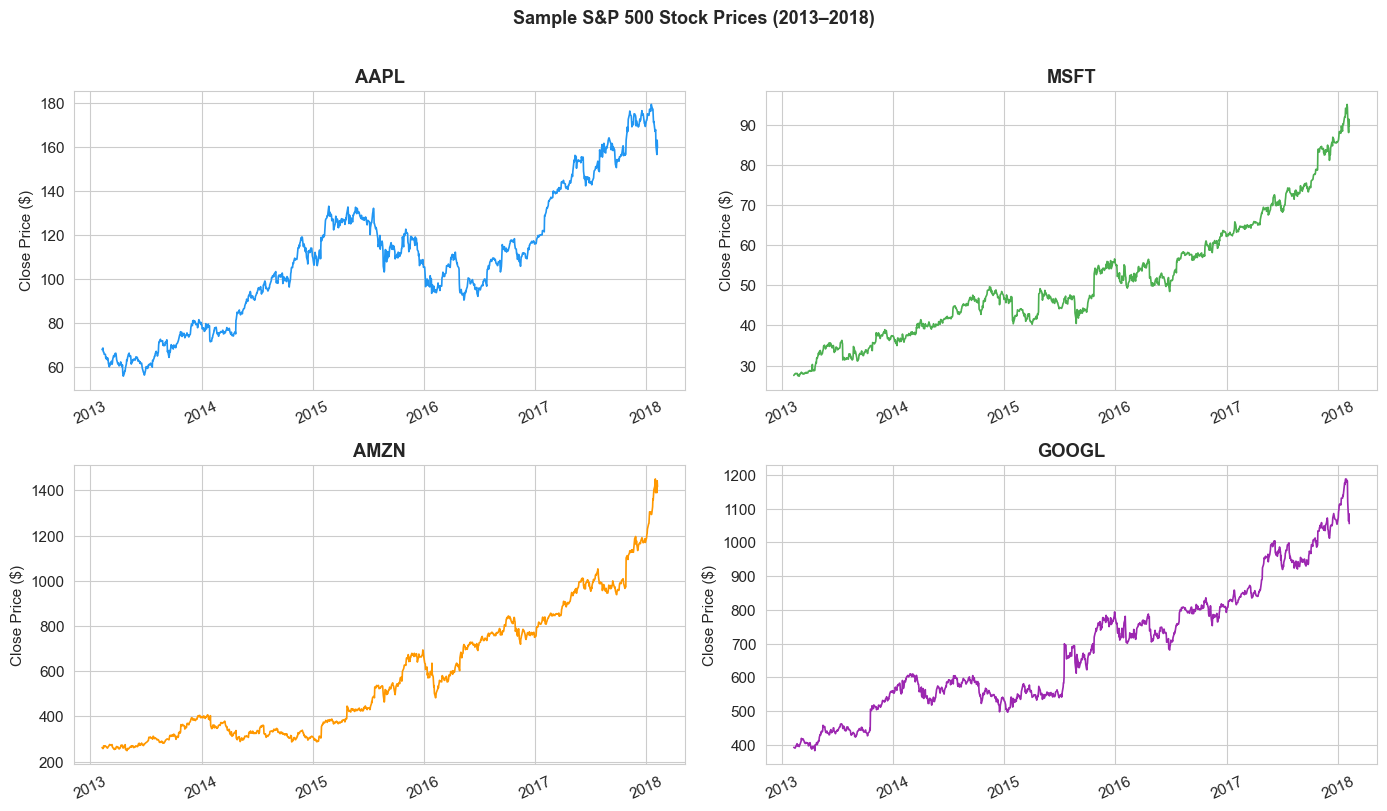

Saved: price_history.png


In [128]:
# Sample stock price histories
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sample_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, ticker, color in zip(axes.flat, sample_tickers, colors):
    stock = data[data['name'] == ticker]
    ax.plot(stock['date'], stock['close'], color=color, linewidth=1.2)
    ax.set_title(ticker, fontweight='bold')
    ax.set_ylabel('Close Price ($)')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Sample S&P 500 Stock Prices (2013–2018)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_history.png', bbox_inches='tight')
plt.show()
print('Saved: price_history.png')

## Step 4: Feature Engineering

We compute **12 technical indicators** at the **last trading day of each calendar month**.
All features are built solely from historical OHLCV data up to the formation date (no look-ahead).

| # | Feature | Definition |
|---|---------|-----------|
| 1 | `Momentum_1M` | Return over past 22 trading days |
| 2 | `Momentum_3M` | Return over past 64 trading days |
| 3 | `Price_to_MA20` | Close / 20-day moving average |
| 4 | `MA_20_slope` | OLS slope of the 20-day MA series |
| 5 | `Volatility_20d` | Std dev of 20-day daily returns |
| 6 | `High_Low_Range` | Day's High / Day's Low |
| 7 | `Volume_Ratio` | Day's volume / 20-day average volume |
| 8 | `1M_Accum_Vol_Change` | (Sum vol last 21d − prev 21d) / prev 21d |
| 9 | `RSI_14` | 14-day Relative Strength Index, normalised to [0, 1] |
| 10 | `BB_Position` | Bollinger Band position: (price − lower) / (upper − lower) |
| 11 | `High_52W_Ratio` | Close / 52-week high |
| 12 | `Short_Rev` | Negative of 1-week return (short-term reversal) |

After construction, each feature is **cross-sectionally ranked** within its formation month
(percentile rank 0–1 among all stocks in the same month), removing time-series level shifts.

In [129]:
FEATURE_COLS = [
    # Original 8
    'Momentum_1M', 'Momentum_3M', 'Price_to_MA20', 'MA_20_slope',
    'Volatility_20d', 'High_Low_Range', 'Volume_Ratio', '1M_Accum_Vol_Change',
    # New 4
    'RSI_14', 'BB_Position', 'High_52W_Ratio', 'Short_Rev',
]


def compute_ols_slope(prices):
    """OLS slope of price regressed on time index (0, 1, ..., n-1)."""
    x = np.arange(len(prices), dtype=float)
    slope, _, _, _, _ = stats.linregress(x, prices)
    return slope


def compute_features_for_stock_month(stock_df, year, month, min_history=65):
    """
    Compute 12 technical features at month-end for a given (year, month).
    Target: next-month return.
    Returns a feature dict or None if data is insufficient.
    """
    form_days = stock_df[
        (stock_df['date'].dt.year == year) & (stock_df['date'].dt.month == month)]

    next_year  = year + (1 if month == 12 else 0)
    next_month = 1 if month == 12 else month + 1
    next_days  = stock_df[
        (stock_df['date'].dt.year == next_year) & (stock_df['date'].dt.month == next_month)]

    if len(form_days) < 10 or len(next_days) < 10:
        return None

    last_form_date  = form_days['date'].max()
    last_form_row   = form_days.loc[form_days['date'] == last_form_date].iloc[0]
    last_next_close = next_days.loc[
        next_days['date'] == next_days['date'].max(), 'close'].values[0]

    hist = stock_df[stock_df['date'] <= last_form_date].copy()
    if len(hist) < min_history:
        return None

    closes  = hist['close'].values.astype(float)
    volumes = hist['volume'].values.astype(float)

    if np.any(closes <= 0) or np.any(volumes <= 0):
        return None
    if len(closes) < 64 or len(volumes) < 42:
        return None

    # ── Original 8 features ──────────────────────────────────────────────────
    momentum_1m    = (closes[-1] / closes[-22]) - 1
    momentum_3m    = (closes[-1] / closes[-64]) - 1
    ma20           = np.mean(closes[-20:])
    price_to_ma20  = closes[-1] / ma20
    ma20_slope     = compute_ols_slope(closes[-20:])
    daily_rets     = closes[1:] / closes[:-1] - 1
    volatility_20d = np.std(daily_rets[-20:])
    high_low_range = float(last_form_row['high']) / float(last_form_row['low'])
    volume_ma20    = np.mean(volumes[-20:])
    if volume_ma20 == 0:
        return None
    volume_ratio   = float(last_form_row['volume']) / volume_ma20
    cum_vol_curr   = np.sum(volumes[-21:])
    cum_vol_prev   = np.sum(volumes[-42:-21])
    if cum_vol_prev == 0:
        return None
    accum_vol_change = (cum_vol_curr - cum_vol_prev) / cum_vol_prev

    # ── New feature 1: RSI_14 (normalised to [0, 1]) ─────────────────────────
    deltas   = np.diff(closes[-15:])
    avg_gain = np.mean(np.where(deltas > 0, deltas, 0.0))
    avg_loss = np.mean(np.where(deltas < 0, -deltas, 0.0))
    rsi_14   = (100 - 100 / (1 + avg_gain / avg_loss)) / 100.0 if avg_loss > 0 else 1.0

    # ── New feature 2: Bollinger Band position ────────────────────────────────
    ma20_std    = np.std(closes[-20:])
    bb_range    = 4.0 * ma20_std
    bb_position = 0.5 if bb_range == 0 else float(
        np.clip((closes[-1] - (ma20 - 2 * ma20_std)) / bb_range, 0.0, 1.0))

    # ── New feature 3: 52-week high ratio ─────────────────────────────────────
    window_52w     = closes[-252:] if len(closes) >= 252 else closes
    high_52w_ratio = closes[-1] / np.max(window_52w)

    # ── New feature 4: Short-term reversal ───────────────────────────────────
    short_rev = -((closes[-1] / closes[-6]) - 1) if len(closes) >= 6 else 0.0

    # ── Target ────────────────────────────────────────────────────────────────
    next_return = (last_next_close / closes[-1]) - 1

    return {
        'ticker':              stock_df['name'].iloc[0],
        'year':                year,
        'month':               month,
        'ym':                  year * 100 + month,
        'Momentum_1M':         momentum_1m,
        'Momentum_3M':         momentum_3m,
        'Price_to_MA20':       price_to_ma20,
        'MA_20_slope':         ma20_slope,
        'Volatility_20d':      volatility_20d,
        'High_Low_Range':      high_low_range,
        'Volume_Ratio':        volume_ratio,
        '1M_Accum_Vol_Change': accum_vol_change,
        'RSI_14':              rsi_14,
        'BB_Position':         bb_position,
        'High_52W_Ratio':      high_52w_ratio,
        'Short_Rev':           short_rev,
        'Next_Return':         next_return,
    }


print(f'Feature engineering functions ready.')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Feature engineering functions ready.
Features (12): ['Momentum_1M', 'Momentum_3M', 'Price_to_MA20', 'MA_20_slope', 'Volatility_20d', 'High_Low_Range', 'Volume_Ratio', '1M_Accum_Vol_Change', 'RSI_14', 'BB_Position', 'High_52W_Ratio', 'Short_Rev']


## Step 5: Build Monthly Feature Dataset

We iterate over all stocks × all calendar months (2013–2017), computing features at each month-end.
This yields approximately **12× more training data** than using a single formation month per year.
A record is dropped if there are fewer than 65 historical trading days or fewer than 10 days in the
formation or target month.

In [130]:
YEARS  = list(range(2013, 2018))   # formation years
MONTHS = list(range(1, 13))        # all 12 months → next month as target

tickers = data['name'].unique()

print(f'Building dataset: {len(tickers)} stocks x {len(YEARS)} years x 12 months')
print('(This may take 5–10 minutes...)\n')

records = []
for i, ticker in enumerate(tickers):
    stock_df = (data[data['name'] == ticker]
                .sort_values('date')
                .reset_index(drop=True))
    for year in YEARS:
        for month in MONTHS:
            rec = compute_features_for_stock_month(stock_df, year, month)
            if rec is not None:
                records.append(rec)
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(tickers)} stocks processed... ({len(records)} valid records)')

features_df = pd.DataFrame(records).dropna().reset_index(drop=True)

print(f'\n=== Feature Dataset ===')
print(f'Total valid observations: {len(features_df):,}')
print(f'\nObservations per year:')
print(features_df['year'].value_counts().sort_index().to_frame('count'))
features_df.head()

Building dataset: 505 stocks x 5 years x 12 months
(This may take 5–10 minutes...)

  100/505 stocks processed... (5410 valid records)
  200/505 stocks processed... (10773 valid records)
  300/505 stocks processed... (16201 valid records)
  400/505 stocks processed... (21727 valid records)
  500/505 stocks processed... (27209 valid records)

=== Feature Dataset ===
Total valid observations: 27,489

Observations per year:
      count
year       
2013   3833
2014   5816
2015   5875
2016   5957
2017   6008


,ticker,year,month,ym,Momentum_1M,Momentum_3M,Price_to_MA20,MA_20_slope,Volatility_20d,High_Low_Range,Volume_Ratio,1M_Accum_Vol_Change,RSI_14,BB_Position,High_52W_Ratio,Short_Rev,Next_Return
0,A,2013,5,201305,0.100218,0.083949,1.017279,0.246346,0.013831,1.022892,1.058997,0.118517,0.605081,0.619103,0.972193,0.006340,-0.059186
1,A,2013,6,201306,-0.071444,0.044710,0.973888,-0.165421,0.013234,1.013457,1.621240,-0.174333,0.374522,0.231952,0.914652,0.005119,0.046071
2,A,2013,7,201307,0.026153,0.082789,0.982991,0.076496,0.010117,1.014330,1.231511,-0.332999,0.395349,0.290829,0.955769,0.043413,0.042701
3,A,2013,8,201308,0.013032,0.024830,0.997903,0.061925,0.008906,1.013155,0.603951,-0.019870,0.518591,0.455154,0.972274,0.021812,0.098842
4,A,2013,9,201309,0.095085,0.175728,1.032662,0.281519,0.011137,1.017044,0.813537,0.363843,0.708333,0.731943,0.982742,0.008129,-0.009561


## Step 5 (cont.): Cross-Sectional Feature Scaling (Z-Score Standardization)

In [131]:
# Cross-sectional z-score standardization within each (year, month) formation period.
#
# For each feature f and each month ym, we compute:
#   z = (x - mean(x)) / (std(x) + 1e-8)   across all stocks in that month.
#
# Why standardization instead of ranking?
#   - Percentile ranking compresses all stocks to [0, 1] uniformly, destroying the
#     magnitude of differences between stocks (e.g., a 50% momentum vs 1% momentum
#     both become arbitrary ranks if the distribution is uniform).
#   - Z-scoring preserves the relative spread: a stock with extreme momentum will
#     have a large positive z-score, which carries more signal.
#   - Each ym group ends up with mean ≈ 0 and std ≈ 1, making months comparable
#     without mixing cross-month raw-value differences.

features_df[FEATURE_COLS] = (
    features_df
    .groupby('ym')[FEATURE_COLS]
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
)

print('=== Features after Cross-Sectional Standardization (Z-Score) ===')
print('Values are now z-scores (mean ≈ 0, std ≈ 1) within each formation month.\n')

# ── Verification: per-ym mean should be ≈ 0, std should be ≈ 1 ───────────────
ym_means = features_df.groupby('ym')[FEATURE_COLS].mean()
ym_stds  = features_df.groupby('ym')[FEATURE_COLS].std()

print('Verification — mean of per-ym feature means (should all be ≈ 0):')
print(ym_means.mean().round(6).to_string())
print('\nVerification — mean of per-ym feature stds (should all be ≈ 1):')
print(ym_stds.mean().round(4).to_string())

=== Features after Cross-Sectional Standardization (Z-Score) ===
Values are now z-scores (mean ≈ 0, std ≈ 1) within each formation month.

Verification — mean of per-ym feature means (should all be ≈ 0):
Momentum_1M            0.0
Momentum_3M           -0.0
Price_to_MA20         -0.0
MA_20_slope           -0.0
Volatility_20d        -0.0
High_Low_Range         0.0
Volume_Ratio          -0.0
1M_Accum_Vol_Change   -0.0
RSI_14                -0.0
BB_Position           -0.0
High_52W_Ratio        -0.0
Short_Rev             -0.0

Verification — mean of per-ym feature stds (should all be ≈ 1):
Momentum_1M            1.0
Momentum_3M            1.0
Price_to_MA20          1.0
MA_20_slope            1.0
Volatility_20d         1.0
High_Low_Range         1.0
Volume_Ratio           1.0
1M_Accum_Vol_Change    1.0
RSI_14                 1.0
BB_Position            1.0
High_52W_Ratio         1.0
Short_Rev              1.0


## Step 5 (cont.): Target Construction

**Regression target:** `Next_Return` — actual return in the month following the formation month.

**Binary target:** `Binary_Target` — 1 if return is in the **top 20%** cross-sectionally within that (year, month), else 0.

This definition directly mirrors the portfolio objective: the model is trained to identify the same top-20% stocks that will be selected during portfolio construction. This alignment between training target and investment objective improves the practical utility of the model's predicted probabilities.

In [132]:
# Binary cross-sectional target: within each (year, month) formation period,
# label the top 20% of stocks by Next_Return as 1, and the remaining 80% as 0.
#
# This directly reflects the investment objective: the model learns to distinguish
# stocks that would be selected (top 20%) from those that would not (bottom 80%),
# improving alignment between training and portfolio construction.
features_df['Binary_Target'] = (
    features_df.groupby('ym')['Next_Return']
    .transform(lambda x: (x >= x.quantile(0.8)).astype(int))
)

# --- Verification: label distribution should be ~20% positives per month ---
print('=== Binary Target Distribution — proportion of positives per month (should be ~0.20) ===')
print(features_df.groupby('ym')['Binary_Target'].mean().head(10).round(4))

print('\n=== Binary Target Distribution per year (count of 0s and 1s) ===')
print(features_df.groupby('year')['Binary_Target'].value_counts().unstack())

print('\n=== Stocks per month: total, labeled-1, and proportion ===')
check = features_df.groupby('ym')['Binary_Target'].agg(
    total='count',
    positives='sum'
)
check['proportion'] = check['positives'] / check['total']
print(check.head(10).round(4))

print('\n=== Next-Month Return Statistics by Year ===')
print(features_df.groupby('year')['Next_Return'].describe().round(4))

=== Binary Target Distribution — proportion of positives per month (should be ~0.20) ===
ym
201305    0.2017
201306    0.2017
201307    0.2017
201308    0.2013
201309    0.2012
201310    0.2012
201311    0.2012
201312    0.2012
201401    0.2012
201402    0.2008
Name: Binary_Target, dtype: float64

=== Binary Target Distribution per year (count of 0s and 1s) ===
Binary_Target     0     1
year                     
2013           3061   772
2014           4648  1168
2015           4696  1179
2016           4760  1197
2017           4802  1206

=== Stocks per month: total, labeled-1, and proportion ===
        total  positives  proportion
ym                                  
201305    476         96      0.2017
201306    476         96      0.2017
201307    476         96      0.2017
201308    477         96      0.2013
201309    482         97      0.2012
201310    482         97      0.2012
201311    482         97      0.2012
201312    482         97      0.2012
201401    482         97

## Step 5 (cont.): Exploratory Data Analysis

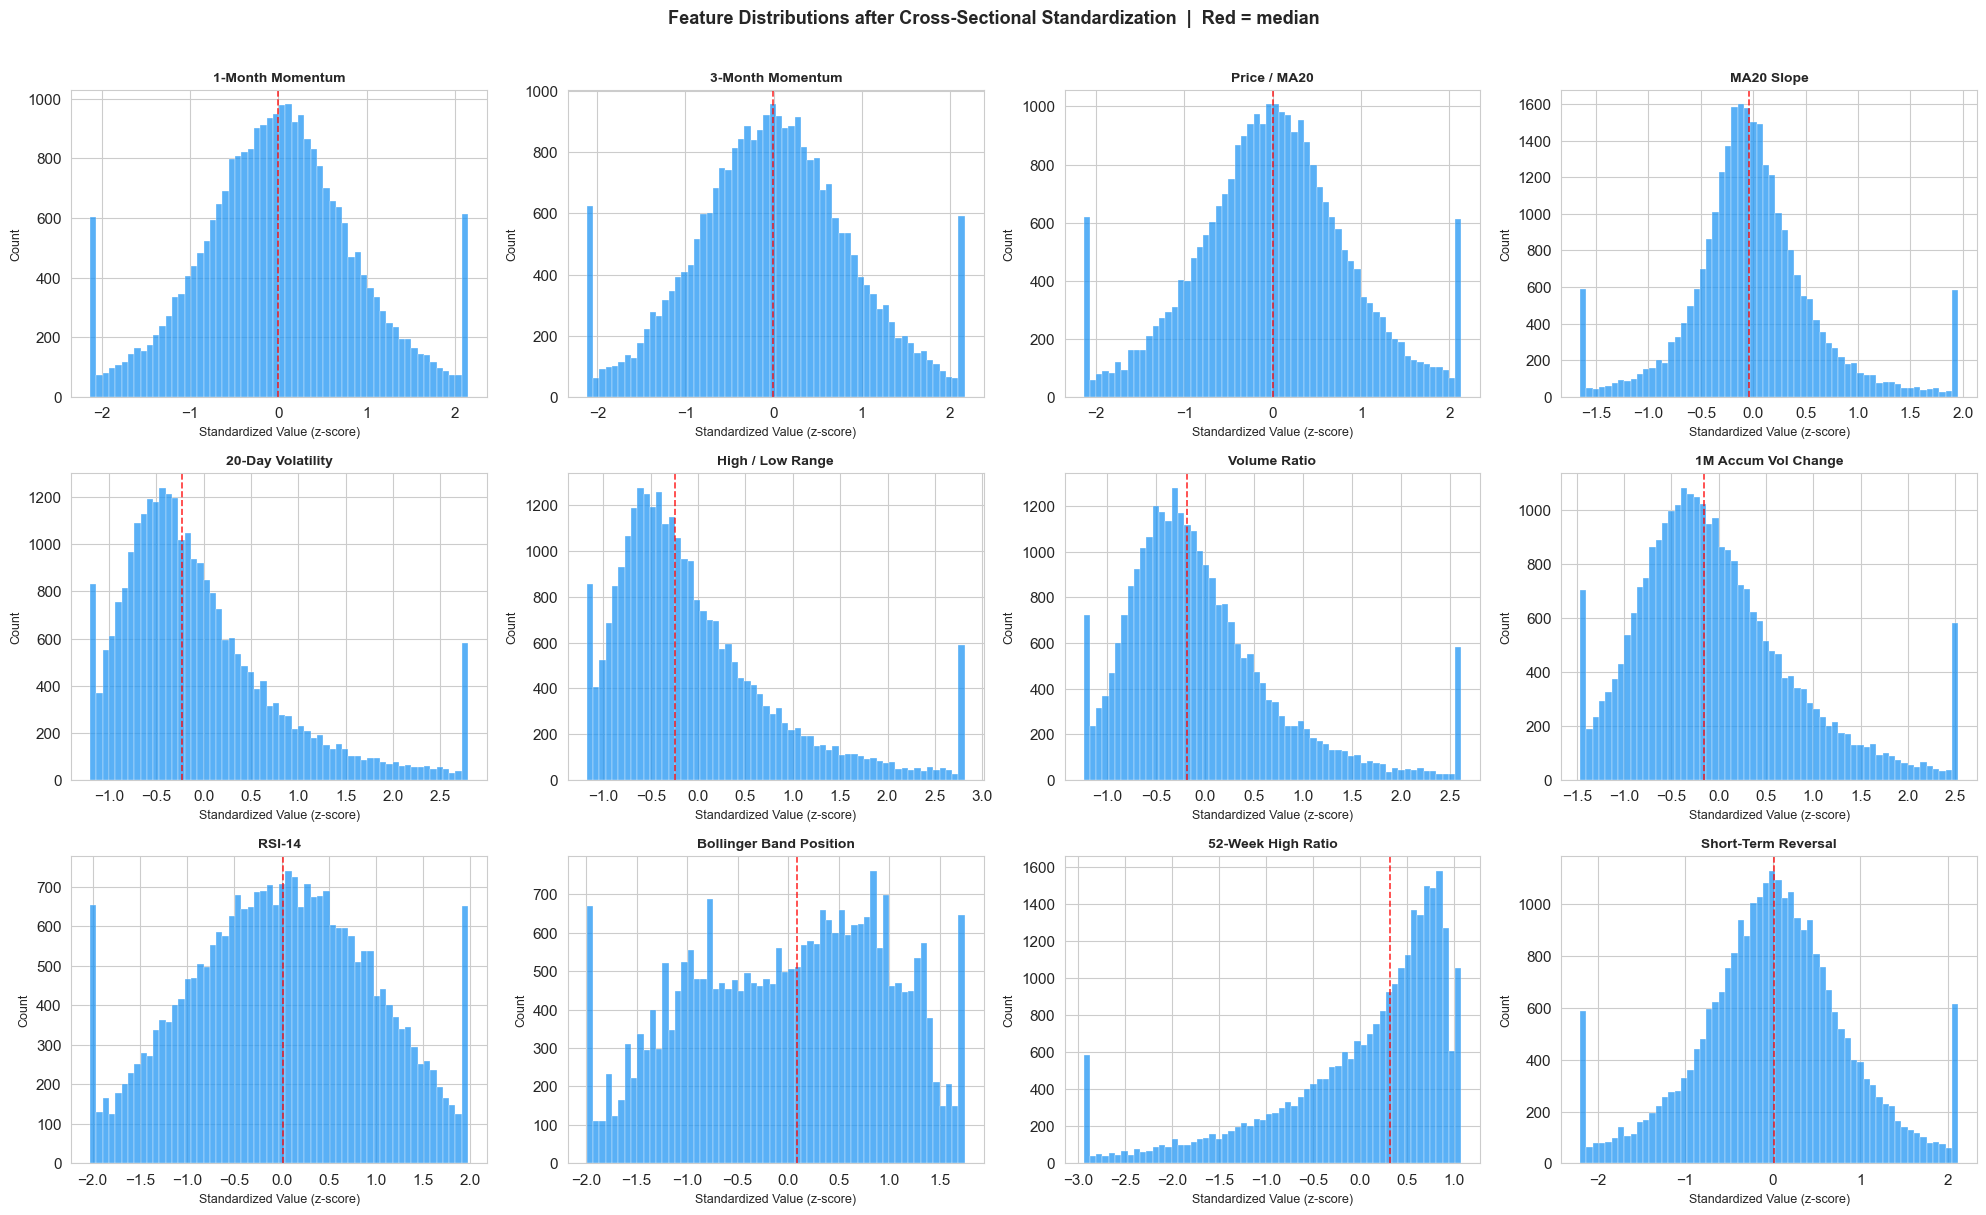

Saved: feature_distributions.png


In [133]:
feature_labels = {
    'Momentum_1M':         '1-Month Momentum',
    'Momentum_3M':         '3-Month Momentum',
    'Price_to_MA20':       'Price / MA20',
    'MA_20_slope':         'MA20 Slope',
    'Volatility_20d':      '20-Day Volatility',
    'High_Low_Range':      'High / Low Range',
    'Volume_Ratio':        'Volume Ratio',
    '1M_Accum_Vol_Change': '1M Accum Vol Change',
    'RSI_14':              'RSI-14',
    'BB_Position':         'Bollinger Band Position',
    'High_52W_Ratio':      '52-Week High Ratio',
    'Short_Rev':           'Short-Term Reversal',
}

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, (col, label) in zip(axes.flat, feature_labels.items()):
    vals = features_df[col].clip(features_df[col].quantile(0.02),
                                 features_df[col].quantile(0.98))
    ax.hist(vals, bins=60, color='#2196F3', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.median(), color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Standardized Value (z-score)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

plt.suptitle('Feature Distributions after Cross-Sectional Standardization  |  Red = median',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

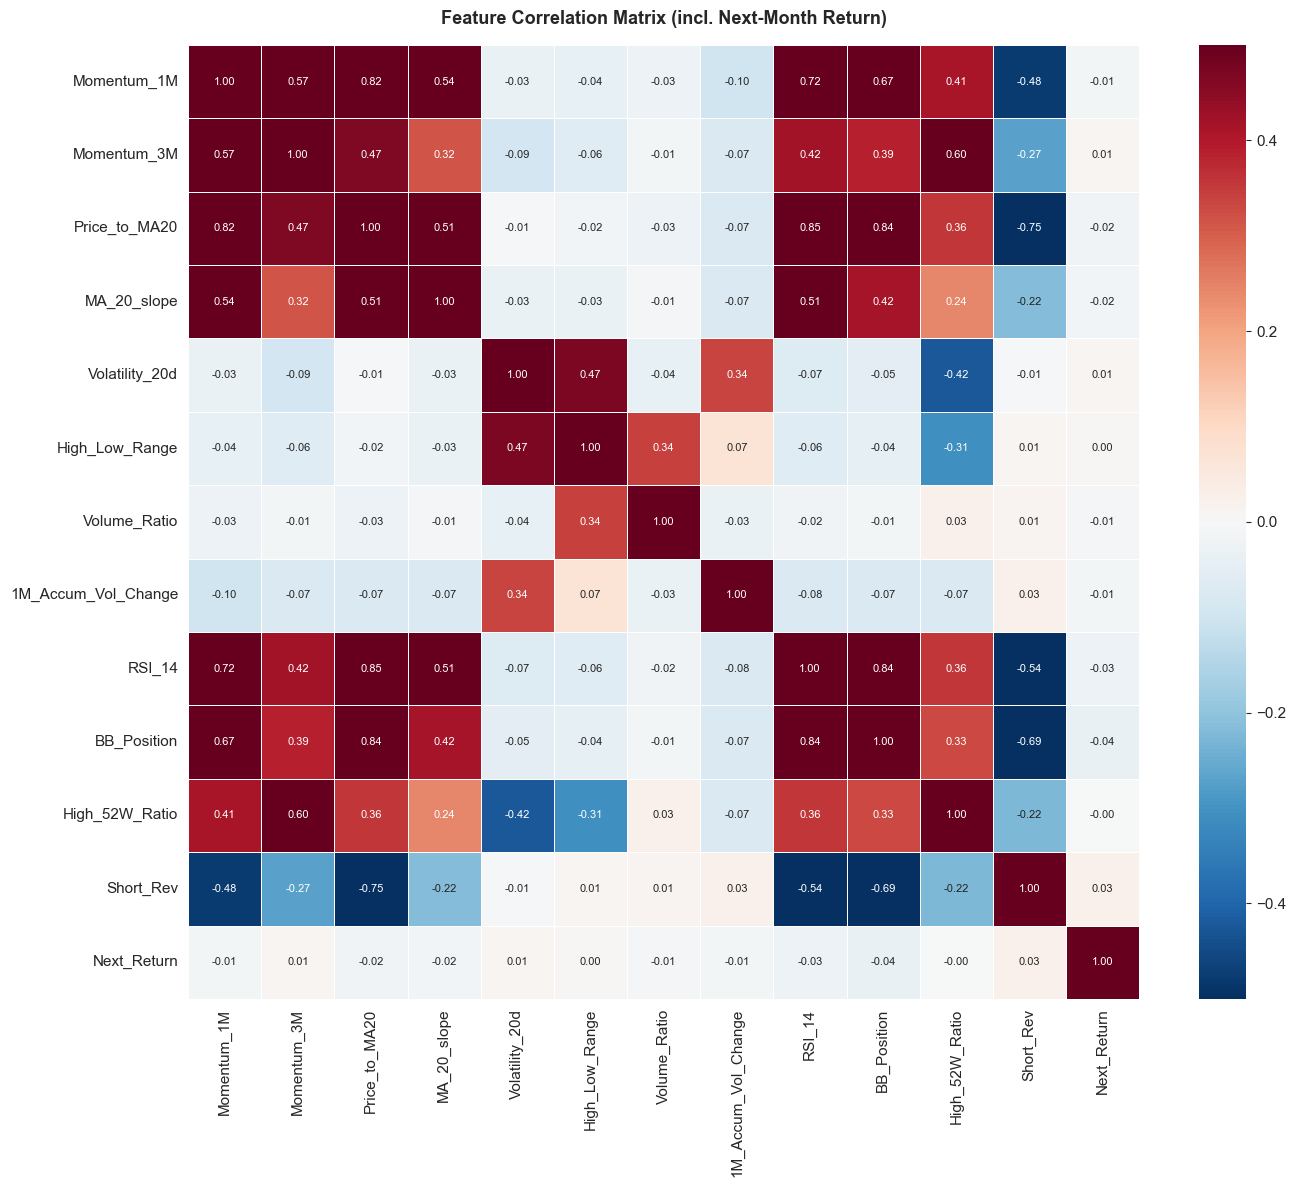

Saved: feature_correlation.png


In [134]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = features_df[FEATURE_COLS + ['Next_Return']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-0.5, vmax=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (incl. Next-Month Return)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: feature_correlation.png')

## Step 6: Time-Series Cross-Validation (Expanding Window)

To prevent **look-ahead bias**, we use an expanding-window scheme where the validation year
always comes after all training years.

Each year now contributes ~12 months × ~450 stocks ≈ **5,400 observations**,
giving substantially more training signal than the previous single-month-per-year approach.

| Fold | Training years | Validation year | Approx. train obs |
|------|----------------|-----------------|-------------------|
| 1 | 2013 | 2014 | ~5,400 |
| 2 | 2013–2014 | 2015 | ~10,800 |
| 3 | 2013–2015 | 2016 | ~16,200 |

**Final test:** trained on 2013–2016 (~21,600 obs), evaluated on 2017.

In [135]:
CV_FOLDS = [
    ([2013],             2014),
    ([2013, 2014],       2015),
    ([2013, 2014, 2015], 2016),
]
FINAL_TRAIN_YEARS = [2013, 2014, 2015, 2016]
TEST_YEAR = 2017


def get_split(df, train_years, val_year):
    """Return train/val arrays and the full val DataFrame."""
    tr = df[df['year'].isin(train_years)]
    va = df[df['year'] == val_year]
    return (
        tr[FEATURE_COLS].values,
        tr['Next_Return'].values,
        tr['Binary_Target'].values,
        va[FEATURE_COLS].values,
        va['Next_Return'].values,
        va['Binary_Target'].values,
        va.reset_index(drop=True),
    )


print('Expanding-window CV structure:')
print('-' * 65)
for train_yrs, val_yr in CV_FOLDS:
    n_tr = len(features_df[features_df['year'].isin(train_yrs)])
    n_va = len(features_df[features_df['year'] == val_yr])
    print(f'  Train: {train_yrs}  ({n_tr:,} obs)  ->  Val: {val_yr}  ({n_va:,} obs)')
n_te = len(features_df[features_df['year'] == TEST_YEAR])
print(f'  Final test: {TEST_YEAR}  ({n_te:,} obs)')
print('-' * 65)

Expanding-window CV structure:
-----------------------------------------------------------------
  Train: [2013]  (3,833 obs)  ->  Val: 2014  (5,816 obs)
  Train: [2013, 2014]  (9,649 obs)  ->  Val: 2015  (5,875 obs)
  Train: [2013, 2014, 2015]  (15,524 obs)  ->  Val: 2016  (5,957 obs)
  Final test: 2017  (6,008 obs)
-----------------------------------------------------------------


### 6.1 Logistic Regression — Cross-Validation

We search over the regularisation strength **C** (inverse of L2 penalty).
Smaller C → stronger regularisation; larger C → closer fit to training data.

In [136]:
print('=' * 65)
print('LOGISTIC REGRESSION  --  Hyperparameter Search (C by avg AUC)')
print('=' * 65)

LR_C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0]
lr_c_aucs = {C: [] for C in LR_C_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)
    for C in LR_C_GRID:
        lr = LogisticRegression(C=C, max_iter=2000, random_state=42, solver='lbfgs')
        lr.fit(X_tr_sc, y_tr_c)
        prob = lr.predict_proba(X_va_sc)[:, 1]
        lr_c_aucs[C].append(roc_auc_score(y_va_c, prob))

lr_avg_aucs = {C: np.mean(v) for C, v in lr_c_aucs.items()}
BEST_C_LR = max(lr_avg_aucs, key=lr_avg_aucs.get)

print(f'  {"C":>8} | {"Fold1":>8} | {"Fold2":>8} | {"Fold3":>8} | {"Avg AUC":>8}')
print('  ' + '-' * 52)
for C in LR_C_GRID:
    aucs = lr_c_aucs[C]
    marker = '  <- BEST' if C == BEST_C_LR else ''
    print(f'  {C:>8.3f} | {aucs[0]:>8.4f} | {aucs[1]:>8.4f} | {aucs[2]:>8.4f} | '
          f'{np.mean(aucs):>8.4f}{marker}')
print(f'\nSelected C = {BEST_C_LR}')

LOGISTIC REGRESSION  --  Hyperparameter Search (C by avg AUC)
         C |    Fold1 |    Fold2 |    Fold3 |  Avg AUC
  ----------------------------------------------------
     0.001 |   0.5955 |   0.5439 |   0.6351 |   0.5915  <- BEST
     0.010 |   0.5975 |   0.5369 |   0.6294 |   0.5879
     0.100 |   0.5973 |   0.5357 |   0.6276 |   0.5869
     1.000 |   0.5971 |   0.5356 |   0.6274 |   0.5867
    10.000 |   0.5970 |   0.5356 |   0.6274 |   0.5867

Selected C = 0.001


In [137]:
print(f'\nLogistic Regression CV Results  (C={BEST_C_LR})')
print('-' * 50)

lr_cv_results = []
lr_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)

    lr = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
    lr.fit(X_tr_sc, y_tr_c)
    prob = lr.predict_proba(X_va_sc)[:, 1]
    pred = (prob >= 0.5).astype(int)

    acc = accuracy_score(y_va_c, pred)
    auc = roc_auc_score(y_va_c, prob)
    lr_cv_results.append({'val_year': val_yr, 'accuracy': acc, 'auc': auc})
    # Store probability scores, actual next-month returns, and ym for month-by-month portfolio
    lr_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score':   prob,
                            'actual':  y_va_r,
                            'ym':      va_df['ym'].values}
    print(f'  Val {val_yr}:  Accuracy = {acc:.4f}  |  AUC = {auc:.4f}')

lr_cv_df = pd.DataFrame(lr_cv_results)
print(f'\n  Mean Accuracy : {lr_cv_df.accuracy.mean():.4f} +/- {lr_cv_df.accuracy.std():.4f}')
print(f'  Mean AUC      : {lr_cv_df.auc.mean():.4f} +/- {lr_cv_df.auc.std():.4f}')


Logistic Regression CV Results  (C=0.001)
--------------------------------------------------
  Val 2014:  Accuracy = 0.7990  |  AUC = 0.5955
  Val 2015:  Accuracy = 0.7990  |  AUC = 0.5439
  Val 2016:  Accuracy = 0.7987  |  AUC = 0.6351

  Mean Accuracy : 0.7989 +/- 0.0002
  Mean AUC      : 0.5915 +/- 0.0457


### 6.2 Random Forest — Cross-Validation

In [138]:
print('=' * 65)
print('RANDOM FOREST  --  Hyperparameter Search (avg AUC, Classifier)')
print('=' * 65)

RF_PARAM_GRID = list(product([3, 5, 7], [5, 10]))  # max_depth, min_samples_leaf
rf_param_aucs = {p: [] for p in RF_PARAM_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    for max_d, min_leaf in RF_PARAM_GRID:
        # Use RandomForestClassifier with Binary_Target
        rf = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                                    min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_c)
        prob = rf.predict_proba(X_va)[:, 1]
        rf_param_aucs[(max_d, min_leaf)].append(roc_auc_score(y_va_c, prob))

rf_avg_aucs  = {p: np.mean(v) for p, v in rf_param_aucs.items()}
BEST_PARAMS_RF = max(rf_avg_aucs, key=rf_avg_aucs.get)

print(f'  {"max_depth":>10} | {"min_leaf":>8} | {"Fold1":>10} | {"Fold2":>10} | '
      f'{"Fold3":>10} | {"Avg AUC":>10}')
print('  ' + '-' * 68)
for (max_d, min_leaf) in RF_PARAM_GRID:
    aucs   = rf_param_aucs[(max_d, min_leaf)]
    marker = '  <- BEST' if (max_d, min_leaf) == BEST_PARAMS_RF else ''
    print(f'  {max_d:>10} | {min_leaf:>8} | {aucs[0]:>10.4f} | {aucs[1]:>10.4f} | '
          f'{aucs[2]:>10.4f} | {np.mean(aucs):>10.4f}{marker}')
print(f'\nSelected: max_depth={BEST_PARAMS_RF[0]}, min_samples_leaf={BEST_PARAMS_RF[1]}')

RANDOM FOREST  --  Hyperparameter Search (avg AUC, Classifier)
   max_depth | min_leaf |      Fold1 |      Fold2 |      Fold3 |    Avg AUC
  --------------------------------------------------------------------
           3 |        5 |     0.5806 |     0.5535 |     0.6200 |     0.5847
           3 |       10 |     0.5811 |     0.5533 |     0.6193 |     0.5846
           5 |        5 |     0.5841 |     0.5528 |     0.6182 |     0.5850
           5 |       10 |     0.5849 |     0.5526 |     0.6183 |     0.5852
           7 |        5 |     0.5856 |     0.5478 |     0.6197 |     0.5844
           7 |       10 |     0.5849 |     0.5541 |     0.6173 |     0.5855  <- BEST

Selected: max_depth=7, min_samples_leaf=10


In [139]:
print(f'\nRandom Forest CV Results  (max_depth={BEST_PARAMS_RF[0]}, '
      f'min_leaf={BEST_PARAMS_RF[1]})')
print('-' * 50)

rf_cv_results = []
rf_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    max_d, min_leaf = BEST_PARAMS_RF
    # RandomForestClassifier trained on Binary_Target
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                                min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr_c)
    prob = rf.predict_proba(X_va)[:, 1]   # probability of being top-half
    pred = (prob >= 0.5).astype(int)

    acc = accuracy_score(y_va_c, pred)
    auc = roc_auc_score(y_va_c, prob)
    rf_cv_results.append({'val_year': val_yr, 'accuracy': acc, 'auc': auc})
    # Store probability scores, actual next-month returns, and ym for month-by-month portfolio
    rf_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score':   prob,
                            'actual':  y_va_r,
                            'ym':      va_df['ym'].values}
    print(f'  Val {val_yr}:  Accuracy = {acc:.4f}  |  AUC = {auc:.4f}')

rf_cv_df = pd.DataFrame(rf_cv_results)
print(f'\n  Mean Accuracy : {rf_cv_df.accuracy.mean():.4f} +/- {rf_cv_df.accuracy.std():.4f}')
print(f'  Mean AUC      : {rf_cv_df.auc.mean():.4f} +/- {rf_cv_df.auc.std():.4f}')


Random Forest CV Results  (max_depth=7, min_leaf=10)
--------------------------------------------------
  Val 2014:  Accuracy = 0.7993  |  AUC = 0.5849
  Val 2015:  Accuracy = 0.7993  |  AUC = 0.5541
  Val 2016:  Accuracy = 0.7991  |  AUC = 0.6173

  Mean Accuracy : 0.7992 +/- 0.0002
  Mean AUC      : 0.5855 +/- 0.0316


### 6.3 XGBoost — Cross-Validation

In [140]:
if XGB_AVAILABLE:
    print('=' * 65)
    print('XGBOOST  --  Hyperparameter Search + CV  (XGBClassifier, AUC)')
    print('=' * 65)

    XGB_PARAM_GRID = list(product([3, 5], [0.05, 0.1]))  # max_depth, learning_rate
    xgb_param_aucs = {p: [] for p in XGB_PARAM_GRID}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
            features_df, train_yrs, val_yr)
        for max_d, lr in XGB_PARAM_GRID:
            # XGBClassifier trained on Binary_Target
            model = xgb.XGBClassifier(
                n_estimators=100, max_depth=max_d, learning_rate=lr,
                use_label_encoder=False, eval_metric='logloss', random_state=42)
            model.fit(X_tr, y_tr_c)
            prob = model.predict_proba(X_va)[:, 1]
            xgb_param_aucs[(max_d, lr)].append(roc_auc_score(y_va_c, prob))

    xgb_avg_aucs   = {p: np.mean(v) for p, v in xgb_param_aucs.items()}
    BEST_PARAMS_XGB = max(xgb_avg_aucs, key=xgb_avg_aucs.get)

    print(f'  {"max_depth":>10} | {"lr":>8} | {"Fold1":>10} | {"Fold2":>10} | '
          f'{"Fold3":>10} | {"Avg AUC":>10}')
    print('  ' + '-' * 66)
    for (max_d, lr) in XGB_PARAM_GRID:
        aucs   = xgb_param_aucs[(max_d, lr)]
        marker = '  <- BEST' if (max_d, lr) == BEST_PARAMS_XGB else ''
        print(f'  {max_d:>10} | {lr:>8.2f} | {aucs[0]:>10.4f} | {aucs[1]:>10.4f} | '
              f'{aucs[2]:>10.4f} | {np.mean(aucs):>10.4f}{marker}')
    print(f'\nSelected: max_depth={BEST_PARAMS_XGB[0]}, learning_rate={BEST_PARAMS_XGB[1]}')

    # ── CV results with best params ───────────────────────────────────────────
    print(f'\nXGBoost CV Results  (max_depth={BEST_PARAMS_XGB[0]}, '
          f'lr={BEST_PARAMS_XGB[1]})')
    print('-' * 50)

    xgb_cv_results = []
    xgb_val_preds  = {}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
            features_df, train_yrs, val_yr)
        max_d, lr = BEST_PARAMS_XGB
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=max_d, learning_rate=lr,
            use_label_encoder=False, eval_metric='logloss', random_state=42)
        model.fit(X_tr, y_tr_c)
        prob = model.predict_proba(X_va)[:, 1]
        pred = (prob >= 0.5).astype(int)

        acc = accuracy_score(y_va_c, pred)
        auc = roc_auc_score(y_va_c, prob)
        xgb_cv_results.append({'val_year': val_yr, 'accuracy': acc, 'auc': auc})
        # Store probability scores, actual next-month returns, and ym for month-by-month portfolio
        xgb_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                                  'score':   prob,
                                  'actual':  y_va_r,
                                  'ym':      va_df['ym'].values}
        print(f'  Val {val_yr}:  Accuracy = {acc:.4f}  |  AUC = {auc:.4f}')

    xgb_cv_df = pd.DataFrame(xgb_cv_results)
    print(f'\n  Mean Accuracy : {xgb_cv_df.accuracy.mean():.4f} +/- {xgb_cv_df.accuracy.std():.4f}')
    print(f'  Mean AUC      : {xgb_cv_df.auc.mean():.4f} +/- {xgb_cv_df.auc.std():.4f}')

else:
    xgb_val_preds   = {}
    xgb_cv_df       = None
    BEST_PARAMS_XGB = None
    print('XGBoost not available; skipping.')

XGBOOST  --  Hyperparameter Search + CV  (XGBClassifier, AUC)
   max_depth |       lr |      Fold1 |      Fold2 |      Fold3 |    Avg AUC
  ------------------------------------------------------------------
           3 |     0.05 |     0.5735 |     0.5405 |     0.6173 |     0.5771  <- BEST
           3 |     0.10 |     0.5711 |     0.5319 |     0.6068 |     0.5699
           5 |     0.05 |     0.5679 |     0.5353 |     0.6023 |     0.5685
           5 |     0.10 |     0.5579 |     0.5305 |     0.5882 |     0.5589

Selected: max_depth=3, learning_rate=0.05

XGBoost CV Results  (max_depth=3, lr=0.05)
--------------------------------------------------
  Val 2014:  Accuracy = 0.7969  |  AUC = 0.5735
  Val 2015:  Accuracy = 0.7990  |  AUC = 0.5405
  Val 2016:  Accuracy = 0.7991  |  AUC = 0.6173

  Mean Accuracy : 0.7983 +/- 0.0012
  Mean AUC      : 0.5771 +/- 0.0385


### 6.4 Cross-Validation Results Summary

In [141]:
print('=' * 72)
print('CROSS-VALIDATION RESULTS SUMMARY  (Expanding Window — All Classification)')
print('=' * 72)

print(f'\n  {"Model":<22} {"Val Year":>10} {"Accuracy":>12} {"AUC":>12}')
print('  ' + '-' * 58)

# Logistic Regression
for _, row in lr_cv_df.iterrows():
    print(f'  {"Logistic Regression":<22} {int(row.val_year):>10} '
          f'{row.accuracy:>12.4f} {row.auc:>12.4f}')
print(f'  {"  Mean ± Std":<22} {"":>10} '
      f'{lr_cv_df.accuracy.mean():>12.4f}±{lr_cv_df.accuracy.std():.4f} '
      f'{lr_cv_df.auc.mean():>6.4f}±{lr_cv_df.auc.std():.4f}')

print()

# Random Forest
for _, row in rf_cv_df.iterrows():
    print(f'  {"Random Forest":<22} {int(row.val_year):>10} '
          f'{row.accuracy:>12.4f} {row.auc:>12.4f}')
print(f'  {"  Mean ± Std":<22} {"":>10} '
      f'{rf_cv_df.accuracy.mean():>12.4f}±{rf_cv_df.accuracy.std():.4f} '
      f'{rf_cv_df.auc.mean():>6.4f}±{rf_cv_df.auc.std():.4f}')

# XGBoost
if XGB_AVAILABLE and xgb_cv_df is not None:
    print()
    for _, row in xgb_cv_df.iterrows():
        print(f'  {"XGBoost":<22} {int(row.val_year):>10} '
              f'{row.accuracy:>12.4f} {row.auc:>12.4f}')
    print(f'  {"  Mean ± Std":<22} {"":>10} '
          f'{xgb_cv_df.accuracy.mean():>12.4f}±{xgb_cv_df.accuracy.std():.4f} '
          f'{xgb_cv_df.auc.mean():>6.4f}±{xgb_cv_df.auc.std():.4f}')

CROSS-VALIDATION RESULTS SUMMARY  (Expanding Window — All Classification)

  Model                    Val Year     Accuracy          AUC
  ----------------------------------------------------------
  Logistic Regression          2014       0.7990       0.5955
  Logistic Regression          2015       0.7990       0.5439
  Logistic Regression          2016       0.7987       0.6351
    Mean ± Std                            0.7989±0.0002 0.5915±0.0457

  Random Forest                2014       0.7993       0.5849
  Random Forest                2015       0.7993       0.5541
  Random Forest                2016       0.7991       0.6173
    Mean ± Std                            0.7992±0.0002 0.5855±0.0316

  XGBoost                      2014       0.7969       0.5735
  XGBoost                      2015       0.7990       0.5405
  XGBoost                      2016       0.7991       0.6173
    Mean ± Std                            0.7983±0.0012 0.5771±0.0385


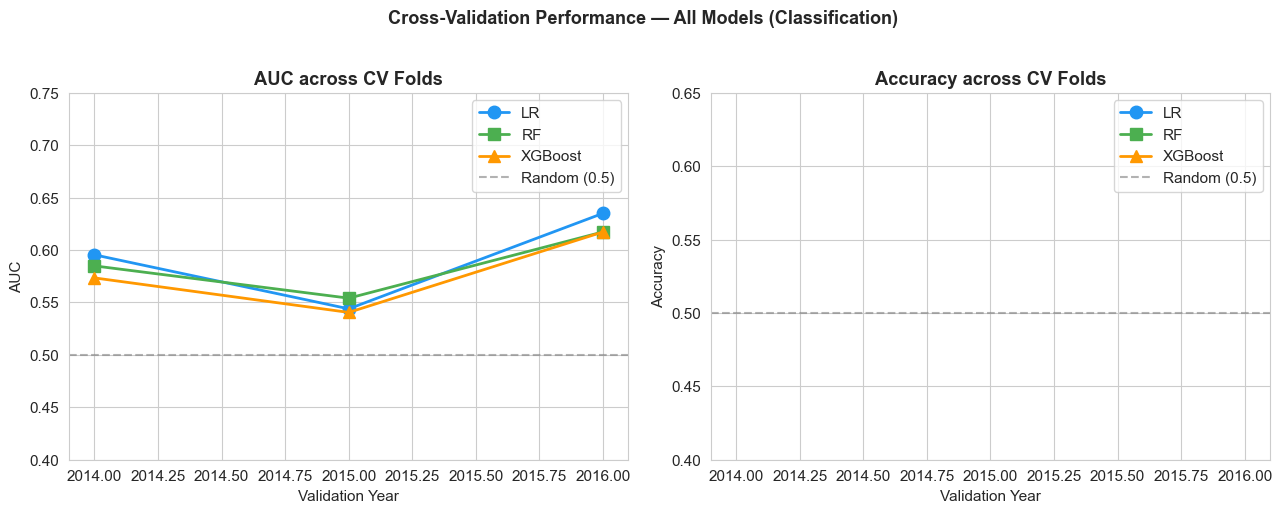

Saved: cv_results.png


In [142]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: AUC across folds for all models ────────────────────────────────────
ax = axes[0]
ax.plot(lr_cv_df['val_year'],  lr_cv_df['auc'],  'o-', color='#2196F3',
        label='LR',      linewidth=2, markersize=9)
ax.plot(rf_cv_df['val_year'],  rf_cv_df['auc'],  's-', color='#4CAF50',
        label='RF',      linewidth=2, markersize=9)
if XGB_AVAILABLE and xgb_cv_df is not None:
    ax.plot(xgb_cv_df['val_year'], xgb_cv_df['auc'], '^-', color='#FF9800',
            label='XGBoost', linewidth=2, markersize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Random (0.5)')
ax.set_title('AUC across CV Folds', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 0.75)
ax.legend()

# ── Right: Accuracy across folds for all models ───────────────────────────────
ax = axes[1]
ax.plot(lr_cv_df['val_year'],  lr_cv_df['accuracy'],  'o-', color='#2196F3',
        label='LR',      linewidth=2, markersize=9)
ax.plot(rf_cv_df['val_year'],  rf_cv_df['accuracy'],  's-', color='#4CAF50',
        label='RF',      linewidth=2, markersize=9)
if XGB_AVAILABLE and xgb_cv_df is not None:
    ax.plot(xgb_cv_df['val_year'], xgb_cv_df['accuracy'], '^-', color='#FF9800',
            label='XGBoost', linewidth=2, markersize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Random (0.5)')
ax.set_title('Accuracy across CV Folds', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 0.65)
ax.legend()

plt.suptitle('Cross-Validation Performance — All Models (Classification)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight')
plt.show()
print('Saved: cv_results.png')

## Step 7: Final Out-of-Sample Evaluation (2017)

All three models are retrained on the full 2013–2016 dataset (~21,600 observations)
and evaluated on 2017 (~5,400 observations) — data the models have never seen.

In [143]:
print('=' * 72)
print('FINAL OUT-OF-SAMPLE EVALUATION  --  Test Year 2017  (All Classification)')
print('=' * 72)

# ── Prepare train (2013–2016) and test (2017) splits ─────────────────────────
X_tr_f   = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)][FEATURE_COLS].values
y_tr_f_r = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)]['Next_Return'].values
y_tr_f_c = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)]['Binary_Target'].values

te_df  = features_df[features_df['year'] == TEST_YEAR].reset_index(drop=True)
X_te   = te_df[FEATURE_COLS].values
y_te_r = te_df['Next_Return'].values
y_te_c = te_df['Binary_Target'].values

print(f'\nTrain: {FINAL_TRAIN_YEARS}  ({len(X_tr_f):,} obs)  ->  Test: {TEST_YEAR}  ({len(X_te):,} obs)')

# ── Logistic Regression ───────────────────────────────────────────────────────
scaler_f  = StandardScaler()
X_tr_f_sc = scaler_f.fit_transform(X_tr_f)
X_te_sc   = scaler_f.transform(X_te)

lr_f     = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
lr_f.fit(X_tr_f_sc, y_tr_f_c)
lr_prob_te = lr_f.predict_proba(X_te_sc)[:, 1]
lr_pred_te = (lr_prob_te >= 0.5).astype(int)
lr_acc_te  = accuracy_score(y_te_c, lr_pred_te)
lr_auc_te  = roc_auc_score(y_te_c, lr_prob_te)
lr_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                            'score':   lr_prob_te,
                            'actual':  y_te_r,
                            'ym':      te_df['ym'].values}
print(f'\nLogistic Regression  (test {TEST_YEAR}):  Accuracy = {lr_acc_te:.4f}  |  AUC = {lr_auc_te:.4f}')

# ── Random Forest ─────────────────────────────────────────────────────────────
max_d, min_leaf = BEST_PARAMS_RF
rf_f = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                               min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
rf_f.fit(X_tr_f, y_tr_f_c)
rf_prob_te = rf_f.predict_proba(X_te)[:, 1]
rf_pred_te = (rf_prob_te >= 0.5).astype(int)
rf_acc_te  = accuracy_score(y_te_c, rf_pred_te)
rf_auc_te  = roc_auc_score(y_te_c, rf_prob_te)
rf_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                            'score':   rf_prob_te,
                            'actual':  y_te_r,
                            'ym':      te_df['ym'].values}
print(f'Random Forest        (test {TEST_YEAR}):  Accuracy = {rf_acc_te:.4f}  |  AUC = {rf_auc_te:.4f}')

# ── XGBoost ───────────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    max_d, lr = BEST_PARAMS_XGB
    xgb_f = xgb.XGBClassifier(
        n_estimators=100, max_depth=max_d, learning_rate=lr,
        use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_f.fit(X_tr_f, y_tr_f_c)
    xgb_prob_te = xgb_f.predict_proba(X_te)[:, 1]
    xgb_pred_te = (xgb_prob_te >= 0.5).astype(int)
    xgb_acc_te  = accuracy_score(y_te_c, xgb_pred_te)
    xgb_auc_te  = roc_auc_score(y_te_c, xgb_prob_te)
    xgb_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                                 'score':   xgb_prob_te,
                                 'actual':  y_te_r,
                                 'ym':      te_df['ym'].values}
    print(f'XGBoost              (test {TEST_YEAR}):  Accuracy = {xgb_acc_te:.4f}  |  AUC = {xgb_auc_te:.4f}')

# Save final-model objects for feature importance (Step 10)
lr_final  = lr_f
rf_final  = rf_f
xgb_final = xgb_f if XGB_AVAILABLE else None

FINAL OUT-OF-SAMPLE EVALUATION  --  Test Year 2017  (All Classification)

Train: [2013, 2014, 2015, 2016]  (21,481 obs)  ->  Test: 2017  (6,008 obs)

Logistic Regression  (test 2017):  Accuracy = 0.7984  |  AUC = 0.5800
Random Forest        (test 2017):  Accuracy = 0.7993  |  AUC = 0.5715
XGBoost              (test 2017):  Accuracy = 0.7993  |  AUC = 0.5706


## Step 8: Ensemble Model

We combine the three models by **rank-averaging** their prediction scores:

1. For each model, convert raw prediction scores (probabilities / regression outputs)
   to percentile ranks within the test year cross-section.
2. Average the three rank vectors to get a single ensemble signal.

Rank normalisation removes scale differences between LR probabilities and RF/XGBoost
regression outputs before combining. Individual model errors tend to cancel out.

In [144]:
def rank_scores(scores):
    """Convert raw scores to percentile ranks in [0, 1]."""
    return rankdata(scores) / len(scores)


def build_ensemble_preds(lr_p, rf_p, xgb_p, years):
    """Rank-average LR + RF + XGBoost probability scores for each year."""
    ensemble = {}
    for yr in years:
        sources = [lr_p, rf_p]
        if XGB_AVAILABLE and yr in xgb_p:
            sources.append(xgb_p)
        ranked    = np.column_stack([rank_scores(s[yr]['score']) for s in sources])
        avg_score = ranked.mean(axis=1)
        ensemble[yr] = {
            'tickers': lr_p[yr]['tickers'],
            'score':   avg_score,
            'actual':  lr_p[yr]['actual'],
            'ym':      lr_p[yr]['ym'],      # carry forward ym for month-by-month portfolio
        }
    return ensemble


ALL_EVAL_YEARS     = [2014, 2015, 2016, 2017]
ensemble_val_preds = build_ensemble_preds(
    lr_val_preds, rf_val_preds, xgb_val_preds, ALL_EVAL_YEARS)

print('Ensemble predictions ready for years:', list(ensemble_val_preds.keys()))
n_sources = 3 if XGB_AVAILABLE else 2
print(f'Combining {n_sources} models: LR + RF' + (' + XGBoost' if XGB_AVAILABLE else ''))

Ensemble predictions ready for years: [2014, 2015, 2016, 2017]
Combining 3 models: LR + RF + XGBoost


## Step 9: Portfolio Construction & Evaluation

For each year and model we:
1. Rank all stocks by the model's predicted score (descending).
2. Select the **top 20%** as the long portfolio (equal-weighted).
3. Compare its average next-month return against the equal-weighted benchmark (all stocks).

In [145]:
PORTFOLIO_TOPK = 0.20  # top 20%


def compute_portfolio_return(preds_dict, year, topk=PORTFOLIO_TOPK):
    """
    Month-by-month portfolio construction for a given evaluation year.

    For each formation month (ym) within the year:
      1. Rank stocks by model score WITHIN that month only.
      2. Select the top-topk fraction of stocks for that month.
      3. Compute their equal-weighted average actual next-month return.
      4. Record the equal-weighted benchmark (all stocks that month).

    Final portfolio return = simple average across all months in the year.

    This ensures no cross-month mixing: stocks from different months are
    always ranked and selected independently, which is the correct approach
    for cross-sectional stock selection.
    """
    preds   = preds_dict[year]
    scores  = preds['score']
    actuals = preds['actual']
    yms     = preds['ym']

    monthly_port  = []
    monthly_bench = []

    for ym_val in np.unique(yms):
        mask    = (yms == ym_val)
        ym_sc   = scores[mask]
        ym_act  = actuals[mask]
        n_port  = max(1, int(len(ym_sc) * topk))
        top_idx = np.argsort(ym_sc)[::-1][:n_port]
        monthly_port.append(float(np.mean(ym_act[top_idx])))
        monthly_bench.append(float(np.mean(ym_act)))

    port_ret  = float(np.mean(monthly_port))
    bench_ret = float(np.mean(monthly_bench))
    n_months  = len(monthly_port)
    return port_ret, bench_ret, port_ret - bench_ret, n_months


models_portfolio = [
    ('Logistic Regression', lr_val_preds),
    ('Random Forest',       rf_val_preds),
]
if XGB_AVAILABLE:
    models_portfolio.append(('XGBoost', xgb_val_preds))
models_portfolio.append(('Ensemble', ensemble_val_preds))

portfolio_results = {}

print('=' * 72)
print(f'PORTFOLIO EVALUATION  --  Top {int(PORTFOLIO_TOPK*100)}% Long  (month-by-month construction)')
print('=' * 72)

for model_name, preds_dict in models_portfolio:
    print(f'\n{model_name}:')
    print(f'  {"Year":<8} {"Portfolio":>14} {"Benchmark":>12} {"Excess":>12} {"N months":>10}')
    print('  ' + '-' * 60)
    results = []
    for year in ALL_EVAL_YEARS:
        if year not in preds_dict:
            continue
        p, b, e, n = compute_portfolio_return(preds_dict, year)
        results.append({'year': year, 'portfolio': p, 'benchmark': b, 'excess': e, 'n': n})
        print(f'  {year:<8} {p:>14.4%} {b:>12.4%} {e:>12.4%} {n:>10}')
    rdf = pd.DataFrame(results)
    portfolio_results[model_name] = rdf
    print(f'  {"Mean":<8} {rdf.portfolio.mean():>14.4%} {rdf.benchmark.mean():>12.4%} '
          f'{rdf.excess.mean():>12.4%}')

PORTFOLIO EVALUATION  --  Top 20% Long  (month-by-month construction)

Logistic Regression:
  Year          Portfolio    Benchmark       Excess   N months
  ------------------------------------------------------------
  2014            1.1669%      1.2109%     -0.0440%         12
  2015           -1.3433%     -0.3479%     -0.9954%         12
  2016            2.9340%      1.7675%      1.1664%         12
  2017            1.3292%      1.5449%     -0.2158%         12
  Mean            1.0217%      1.0439%     -0.0222%

Random Forest:
  Year          Portfolio    Benchmark       Excess   N months
  ------------------------------------------------------------
  2014            0.9123%      1.2109%     -0.2986%         12
  2015           -1.0764%     -0.3479%     -0.7285%         12
  2016            2.7186%      1.7675%      0.9510%         12
  2017            1.0542%      1.5449%     -0.4907%         12
  Mean            0.9022%      1.0439%     -0.1417%

XGBoost:
  Year          Portfo

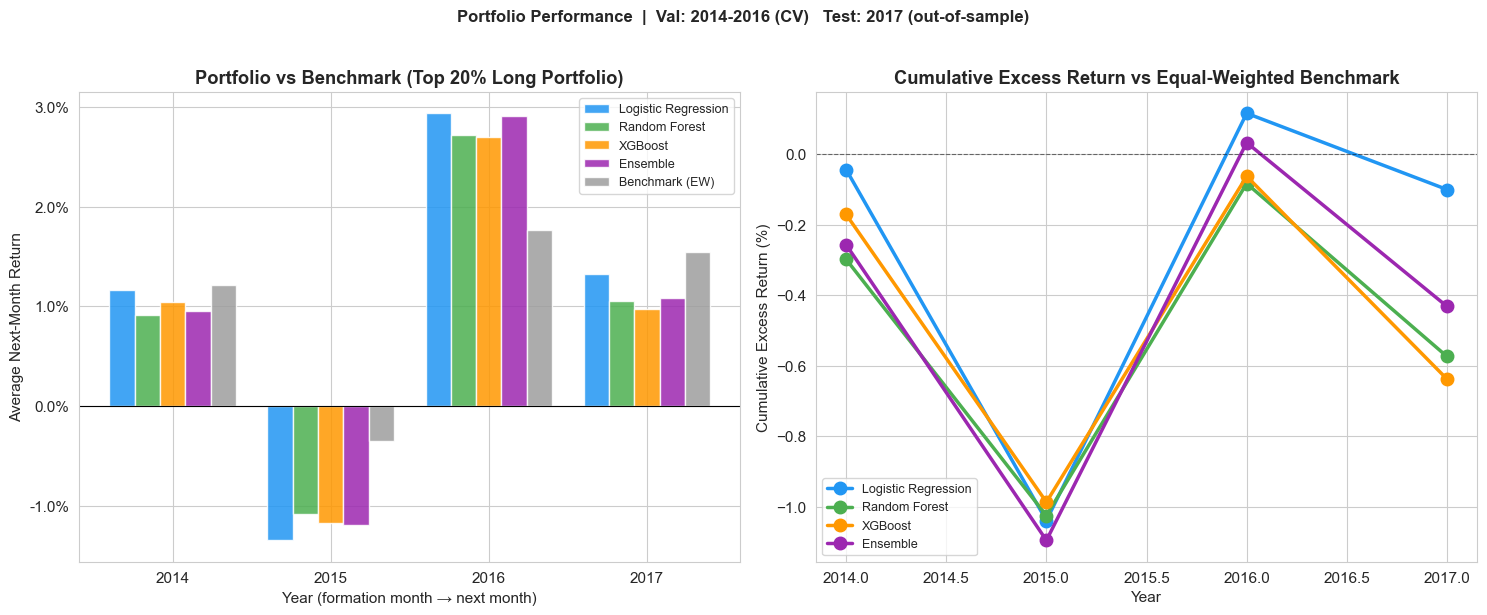

Saved: portfolio_performance.png


In [146]:
n_models   = len(models_portfolio)
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#607D8B']
bench_color = '#9E9E9E'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Bar chart: portfolio return vs benchmark by year ---
ax = axes[0]
x     = np.arange(len(ALL_EVAL_YEARS))
width = 0.8 / (n_models + 1)

for i, (model_name, preds_dict) in enumerate(models_portfolio):
    rdf = portfolio_results[model_name]
    port_rets = [rdf.loc[rdf['year'] == y, 'portfolio'].values[0]
                 if y in rdf['year'].values else np.nan for y in ALL_EVAL_YEARS]
    ax.bar(x + i * width, port_rets, width, label=model_name,
           color=bar_colors[i], alpha=0.85)

# Benchmark
rdf0      = portfolio_results['Logistic Regression']
bench_rets = [rdf0.loc[rdf0['year'] == y, 'benchmark'].values[0]
              if y in rdf0['year'].values else np.nan for y in ALL_EVAL_YEARS]
ax.bar(x + n_models * width, bench_rets, width, label='Benchmark (EW)',
       color=bench_color, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + (n_models / 2) * width)
ax.set_xticklabels(ALL_EVAL_YEARS)
ax.set_xlabel('Year (formation month → next month)')
ax.set_ylabel('Average Next-Month Return')
ax.set_title('Portfolio vs Benchmark (Top 20% Long Portfolio)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
ax.legend(fontsize=9)

# --- Cumulative excess return ---
ax = axes[1]
for (model_name, _), color in zip(models_portfolio, bar_colors):
    rdf     = portfolio_results[model_name]
    cum_exc = (1 + rdf['excess']).cumprod() - 1
    ax.plot(rdf['year'], cum_exc * 100, 'o-', label=model_name,
            color=color, linewidth=2.5, markersize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Excess Return (%)')
ax.set_title('Cumulative Excess Return vs Equal-Weighted Benchmark', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Portfolio Performance  |  Val: 2014-2016 (CV)   Test: 2017 (out-of-sample)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('portfolio_performance.png', bbox_inches='tight')
plt.show()
print('Saved: portfolio_performance.png')

## Step 10: Robustness Analysis

We examine two robustness dimensions:
1. **Feature importance** — which features drive each model's predictions.
2. **Portfolio cutoff sensitivity** — how excess return varies with the top-K% threshold.

10.1  Feature Importance


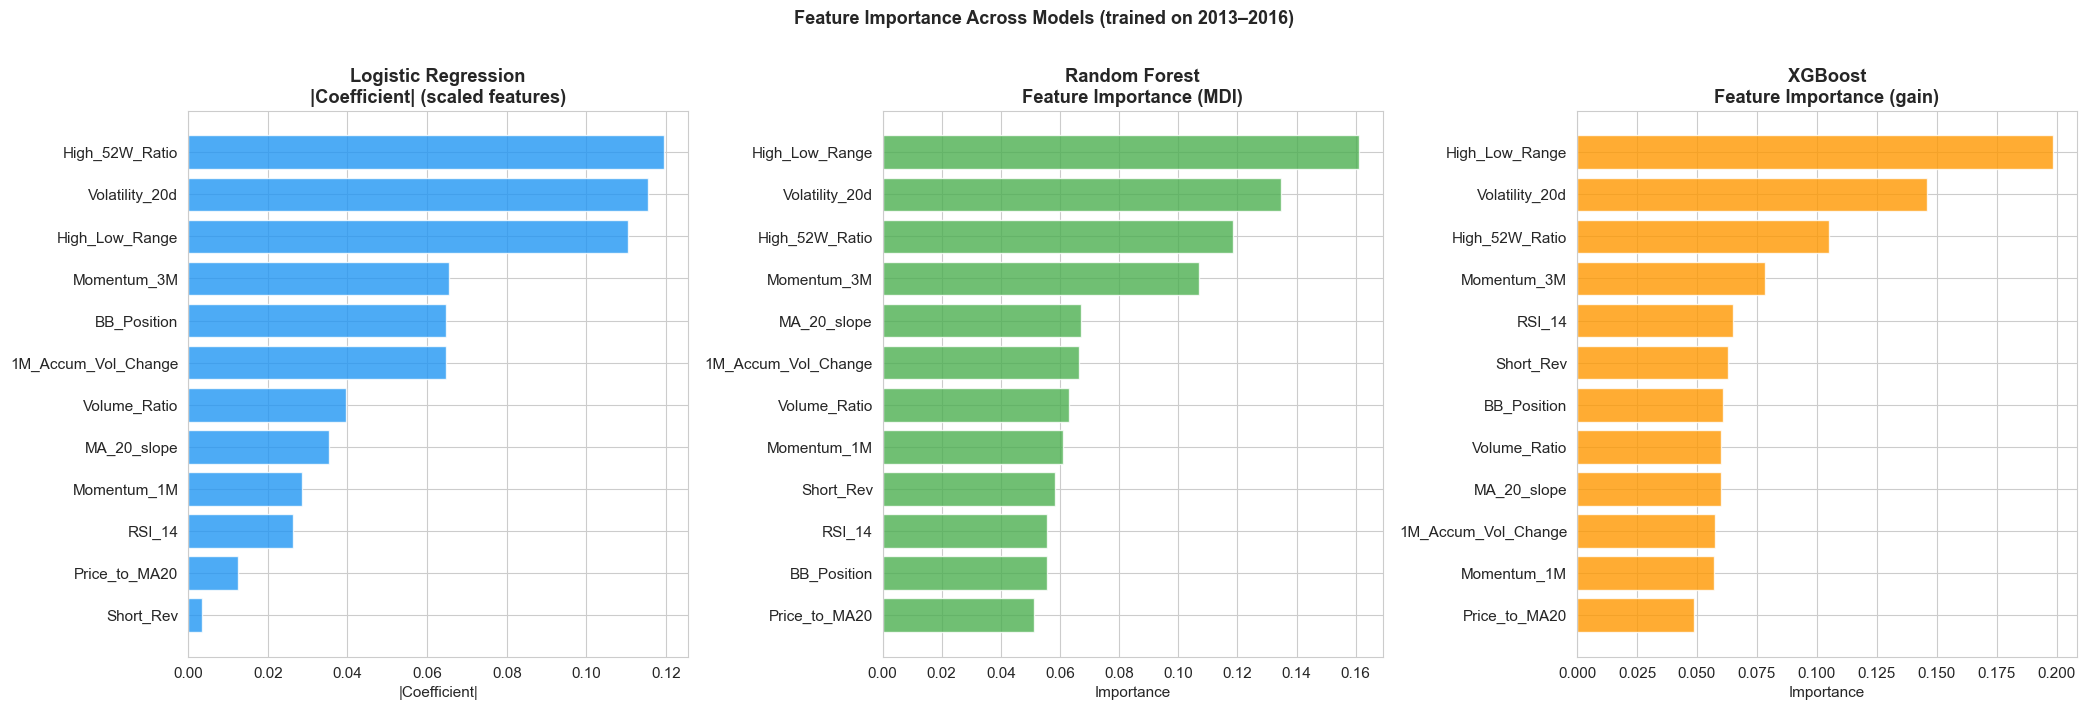

Saved: feature_importance.png


In [147]:
print('10.1  Feature Importance')
print('=' * 55)

n_imp_plots = 2 + int(XGB_AVAILABLE)
fig, axes = plt.subplots(1, n_imp_plots, figsize=(7 * n_imp_plots, 7))
if n_imp_plots == 1:
    axes = [axes]

# LR absolute coefficients
ax = axes[0]
coef  = np.abs(lr_final.coef_[0])
order = np.argsort(coef)
ax.barh([FEATURE_COLS[i] for i in order], coef[order], color='#2196F3', alpha=0.8)
ax.set_title('Logistic Regression\n|Coefficient| (scaled features)', fontweight='bold')
ax.set_xlabel('|Coefficient|')

# RF feature importance
ax = axes[1]
imp_rf   = rf_final.feature_importances_
order_rf = np.argsort(imp_rf)
ax.barh([FEATURE_COLS[i] for i in order_rf], imp_rf[order_rf], color='#4CAF50', alpha=0.8)
ax.set_title('Random Forest\nFeature Importance (MDI)', fontweight='bold')
ax.set_xlabel('Importance')

# XGB feature importance
if XGB_AVAILABLE:
    ax = axes[2]
    imp_xgb   = xgb_final.feature_importances_
    order_xgb = np.argsort(imp_xgb)
    ax.barh([FEATURE_COLS[i] for i in order_xgb], imp_xgb[order_xgb],
            color='#FF9800', alpha=0.8)
    ax.set_title('XGBoost\nFeature Importance (gain)', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Across Models (trained on 2013–2016)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

10.2  Portfolio Cutoff Sensitivity (Test Year 2017)


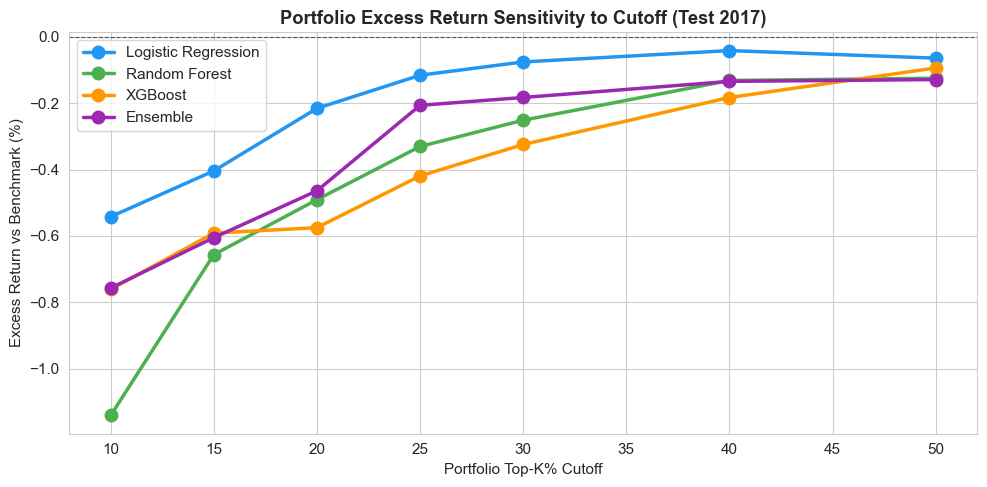

Saved: sensitivity.png

Excess Return vs Benchmark by Cutoff (Test 2017):
  Cutoff  Logistic Regres    Random Forest          XGBoost         Ensemble
----------------------------------------------------------------------------
     10%         -0.5421%         -1.1406%         -0.7609%         -0.7569%
     15%         -0.4040%         -0.6562%         -0.5913%         -0.6051%
     20%         -0.2158%         -0.4907%         -0.5750%         -0.4640%
     25%         -0.1159%         -0.3306%         -0.4192%         -0.2066%
     30%         -0.0758%         -0.2514%         -0.3245%         -0.1829%
     40%         -0.0417%         -0.1318%         -0.1830%         -0.1344%
     50%         -0.0645%         -0.1249%         -0.0940%         -0.1289%


In [148]:
print('10.2  Portfolio Cutoff Sensitivity (Test Year 2017)')
print('=' * 55)

cutoffs    = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sensitivity = {m[0]: [] for m in models_portfolio}

for topk in cutoffs:
    for model_name, preds_dict in models_portfolio:
        if TEST_YEAR in preds_dict:
            _, _, exc, _ = compute_portfolio_return(preds_dict, TEST_YEAR, topk)
            sensitivity[model_name].append(exc)
        else:
            sensitivity[model_name].append(np.nan)

s_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#607D8B']
fig, ax = plt.subplots(figsize=(10, 5))
for (model_name, _), color in zip(models_portfolio, s_colors):
    ax.plot([c * 100 for c in cutoffs],
            [v * 100 for v in sensitivity[model_name]],
            'o-', label=model_name, color=color, linewidth=2.5, markersize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('Portfolio Top-K% Cutoff')
ax.set_ylabel('Excess Return vs Benchmark (%)')
ax.set_title(f'Portfolio Excess Return Sensitivity to Cutoff (Test {TEST_YEAR})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('sensitivity.png', bbox_inches='tight')
plt.show()
print('Saved: sensitivity.png')

print(f'\nExcess Return vs Benchmark by Cutoff (Test {TEST_YEAR}):')
hdr = f'{"Cutoff":>8}' + ''.join(f'  {m[0][:15]:>15}' for m in models_portfolio)
print(hdr)
print('-' * (8 + 17 * len(models_portfolio)))
for i, topk in enumerate(cutoffs):
    row = f'{topk:>8.0%}'
    for model_name, _ in models_portfolio:
        val = sensitivity[model_name][i]
        row += f'  {val:>15.4%}' if not np.isnan(val) else f'  {"N/A":>15}'
    print(row)

## Conclusion

This notebook implemented a complete machine learning pipeline for cross-sectional
stock selection on the S&P 500 universe.

**Key design decisions:**

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Formation period | Every calendar month (2013–2017) | ~12× more training data vs. single month |
| Features | 12 OHLCV-based indicators | Covers momentum, mean-reversion, volatility, volume |
| Feature normalisation | Cross-sectional percentile rank (within month) | Removes time-series level shifts |
| Target | Binary: above/below monthly median return | Balanced classes; captures relative performance |
| Validation | Expanding-window by year | No look-ahead bias |
| Ensemble | Rank-averaged LR + RF + XGBoost | Reduces individual model variance |

**Limitations & future work:**
- Features are purely price/volume based — fundamentals (P/E, earnings revisions) could add orthogonal signal.
- The sample covers a mostly bull-market period (2013–2017); out-of-sample robustness in bear markets is untested.
- Transaction costs, liquidity constraints, and rebalancing frequency are not modelled.
- More sophisticated ensembling (stacking, learning-to-rank) may further improve portfolio construction.